# STRUMENTI INFORMATICI B, Tommaso Casazza

Questo notebook è il progetto che consegno per il corso di Strumenti informatici B. L'idea alla base è quella di utilizzare le conoscenze maturate durante il corso e applicarle ad una situazione reale. In particolare presento un fac simile di parte dell'analisi dati svolta per un corso di laboratorio.

# SODIUM LAMP EMISSION ANALYSIS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Importare i dati

Importo i dati acquisiti dal monocromatore e normalizzo le intensità: l'analisi seguente si concentrerà sullo studio della posizione e della forma dei picchi in qunato non sono stati acquisiti dati ottimizzati per il confronto delle intensità assolute tra i diversi spettri.

In [2]:
main_1 = np.loadtxt("Measurement_data/10-14-002.txt", usecols=(0,1))
main_2 = np.loadtxt("Measurement_data/10-14-003.txt", usecols=(0,1))
main_3 = np.loadtxt("Measurement_data/10-14-004.txt", usecols=(0,1))
main_4 = np.loadtxt("Measurement_data/10-14-005.txt", usecols=(0,1))
sec_1 = np.loadtxt("Measurement_data/10-14-006.txt", usecols=(0,1))
sec_2 = np.loadtxt("Measurement_data/10-14-007.txt", usecols=(0,1))
sec_3 = np.loadtxt("Measurement_data/10-14-008.txt", usecols=(0,1))
sec_3 = sec_3[::-1] # the measurement was run backwards, I invert it to get it in the forward direction.

# I normalize the intensities

main_1 = main_1*([1,1/np.max(main_1[:,1])])
main_2 = main_2*([1,1/np.max(main_2[:,1])])
main_3 = main_3*([1,1/np.max(main_3[:,1])])
main_4 = main_4*([1,1/np.max(main_4[:,1])])
sec_1 = sec_1*([1,1/np.max(sec_1[:,1])])
sec_2 = sec_2*([1,1/np.max(sec_2[:,1])])
sec_3 = sec_3*([1,1/np.max(sec_3[:,1])]) 

# vectors that represent the slit apertures for each measurement

main_slits = np.array([0.07, 0.035, 0.024, 0.024]) # mm
sec_slits = np.array([0.06, 0.03, 0.03]) # mm

Plotto i dati acquisiti

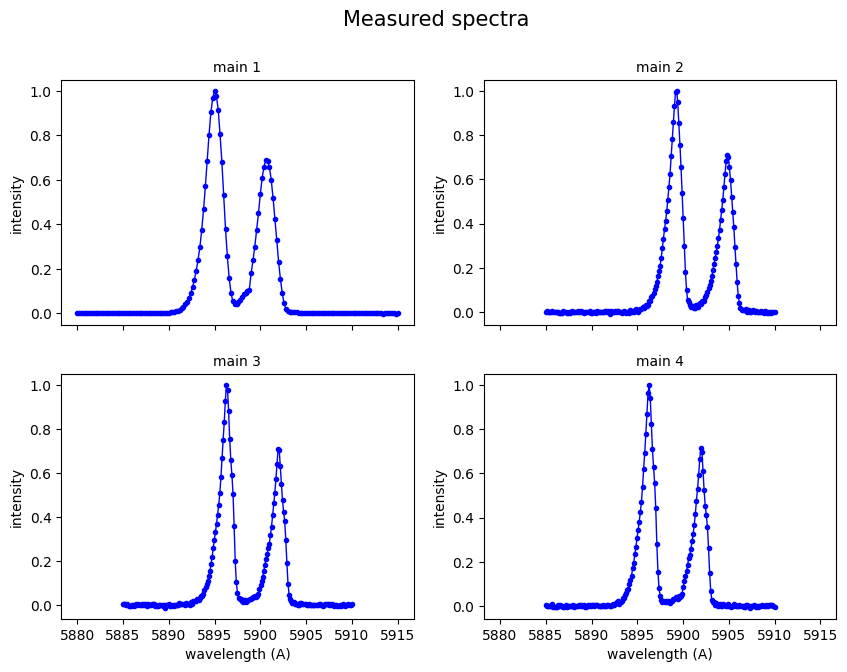

In [3]:
# main spectrum

fig_main, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2, 2, figsize = (10, 7), sharey = False, sharex = True)
ax1.plot(main_1[:,0], main_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax2.plot(main_2[:,0], main_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax3.plot(main_3[:,0], main_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax4.plot(main_4[:,0], main_4[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax1.set_title('main 1', fontsize = 10)
ax2.set_title('main 2', fontsize = 10)
ax3.set_title('main 3', fontsize = 10)
ax4.set_title('main 4', fontsize = 10)
fig_main.suptitle('Measured spectra', fontsize = 15)
ax3.set_xlabel('wavelength (A)', fontsize = 10)
ax4.set_xlabel('wavelength (A)', fontsize = 10)
for ax in fig_main.axes:
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

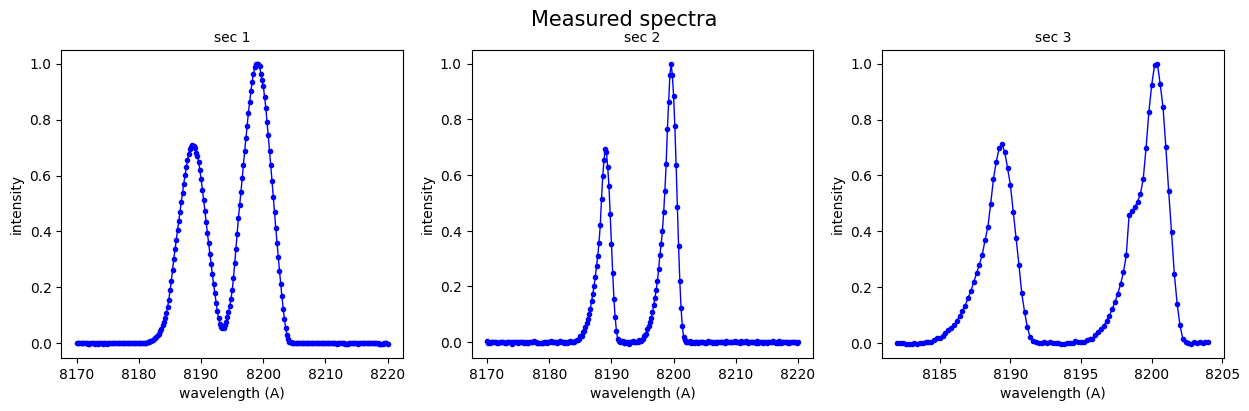

In [4]:
# secondary spectrum

fig_sec, ((ax1, ax2, ax3)) = plt.subplots(1,3, figsize = (15, 4), sharey = False, sharex = False)
ax1.plot(sec_1[:,0], sec_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax2.plot(sec_2[:,0], sec_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax3.plot(sec_3[:,0], sec_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax1.set_title('sec 1', fontsize = 10)
ax2.set_title('sec 2', fontsize = 10)
ax3.set_title('sec 3', fontsize = 10)
fig_sec.suptitle('Measured spectra', fontsize = 15)
for ax in fig_sec.axes:
    ax.set_xlabel('wavelength (A)', fontsize = 10)
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

Osservo che le forme spettrali non sono gaussiane/lorentziane perfettamente simmetriche e ben definite: il monocromatore aggiunge delle aberrazioni (particolarmente visibili negli spettri main_3 e main_4, relativi a slit molto chiuse). Per questo motivo nella successiva analisi dati selezionerò (roughly) ed analizzerò solo i picchi, che sono meno influenzati da questa asimmetria. 
Nota:  procedo in questo modo perchè in letteratura è ampiamente documentata (a livello teorico e sperimentale) la simmetria di queste linee spettrali, il che mi fa concludere che l'asimmetria è dovuta al mio setup/monocromatore. 

## Procedura di fitting

Innanzitutto importo il modulo che contiene le funzioni utili alla procedura di fitting:

In [5]:
import fitting_functions as ff

### Spettro principale

In [6]:
main_meas = (main_1, main_2, main_3, main_4) # list with the main variables

# I create the vectors that I'm gonna populate when doing the fits
max_main = np.ones((2,len(main_meas),2)) # will contain the position of the max of the peaks
FWHM_main = np.ones((2,len(main_meas),2)) # will contain the FWHM of the peaks

Ora cerco i (2) picchi degli spettri con $\textit{select\_2peaks()}$ e eseguo fit gaussiani e lorentziani: per decidere quale dei due utilizzare confronto la somma dei residui quadrati. Di ciascun picco calcolo la posizione del massimo e la FWHM.

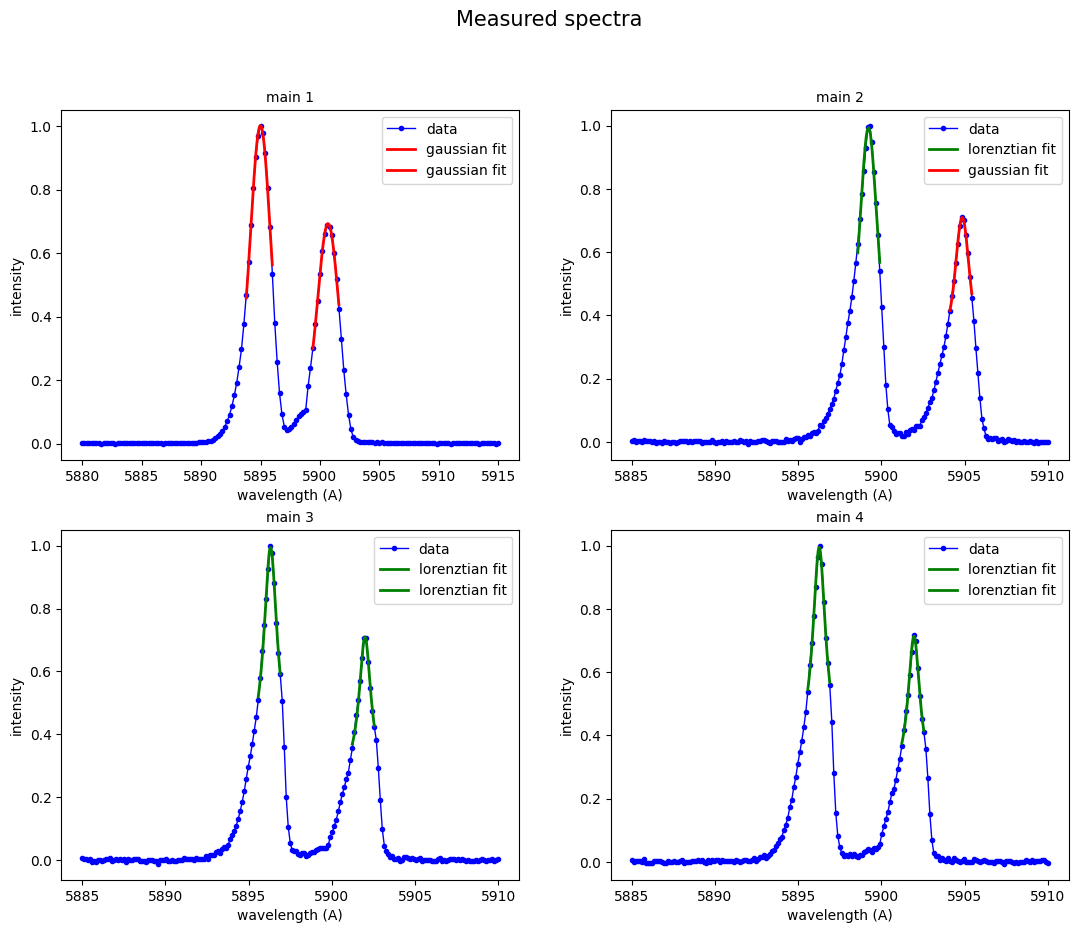

In [10]:
# I create the figure that I am gonna populate with the fit plots
fig_main, axs = plt.subplots(2, 2, figsize = (13, 10), sharey = False, sharex = False)
axs[0][0].plot(main_1[:,0], main_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[0][1].plot(main_2[:,0], main_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[1][0].plot(main_3[:,0], main_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[1][1].plot(main_4[:,0], main_4[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[0][0].set_title('main 1', fontsize = 10)
axs[0][1].set_title('main 2', fontsize = 10)
axs[1][0].set_title('main 3', fontsize = 10)
axs[1][1].set_title('main 4', fontsize = 10)
fig_main.suptitle('Measured spectra', fontsize = 15)
for ax in fig_main.axes:
    ax.set_xlabel('wavelength (A)', fontsize = 10)
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

# I execute the fits and populate the figure
for kk in range (len(main_meas)): # loop over the measurements
    pk_1, pk_2 = ff.select_2peaks(main_meas[kk], 20, 6, 0.1) # this selects a neighborhood of the two peaks
    pk_ranges = (pk_1, pk_2)
    for jj in (0,1): # loop over the peak 1 and 2 of each measurement
        pk = pk_ranges[jj] # selects which peak is to be analized
        mean = np.average(pk[:,0], weights=pk[:,1])
        sigma = np.std(pk[:,0], mean=mean)
        p_guess = ([1, mean, sigma, 0]) #starting point in the fit (a, x0, sigma, y0): ESSENTIAL
        g_param, g_cov, g_infodict, ier, msg = curve_fit(ff.gaussian, pk[:,0], pk[:,1], p_guess, full_output=True) 
        l_param, l_cov, l_infodict, ier, msg = curve_fit(ff.lorentzian, pk[:,0], pk[:,1], p_guess, full_output=True)
        # assuming independent variables
        g_err = np.sqrt(np.diag(g_cov))
        l_err = np.sqrt(np.diag(l_cov))
        # sum of squared residulas, used as a measure of the goodness of the fit (the smaller the better)
        g_confidence = sum(g_infodict["fvec"]**2) 
        l_confidence = sum(l_infodict["fvec"]**2)

        # I decide which fit (function) is to be used
        if g_confidence < l_confidence: 
            
            # I populate the max vector
            max_main[0,kk,jj] = g_param[1] # for each column and layer the first row contains the value
            max_main[1,kk,jj] = g_err[1] # for each column and layer the second row contains the error

            # I populate the FWHM vector
            FWHM_main[0,kk,jj] = 2.3548 * g_param[2]
            FWHM_main[1,kk,jj] = 2.3548 * g_err[2]

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[int((kk+1)/3)][int((kk+2)%2)].plot(xrange,ff.gaussian(xrange,*g_param), color = 'red', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "gaussian fit")
            axs[int((kk+1)/3)][int((kk+2)%2)].legend(fontsize = 10)
        else: 
            # I populate the max vector
            max_main[0,kk,jj] = l_param[1]
            max_main[1,kk,jj] = l_err[1]

            # I populate the FWHM vector
            FWHM_main[0,kk,jj]=2*l_param[2]
            FWHM_main[1,kk,jj]=2*l_err[2]

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[int((kk+1)/3)][int((kk+2)%2)].plot(xrange,ff.lorentzian(xrange,*l_param), color = 'green', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "lorenztian fit")
            axs[int((kk+1)/3)][int((kk+2)%2)].legend(fontsize = 10)

Nella procedura di fitting appena svolta è essenziale inserire gli starting point dei parametri nel fit, se questi sono assenti o non particolarmente azzeccati il fit fallirà quasi sicuramente. Inserire un valore manualmente "ad occhio" che possa portare ad un fit significativo assomiglia più a magia nera che ad una scienza: è meglio implementare una qualche procedura (per quanto basilare) per "guidare" il fit. In questo caso la soluzione di fornire la media e la deviazione standard dei dataset nel vettore $\textit{p\_guess}$ sembra bastare.

### Spettro secondario

Ripeto la procedura appena svolta sullo spettro principale per analizzare lo spettro secondario: sono valide le stesse ipotesi e considerazioni.

In [38]:
sec_meas = (sec_1, sec_2, sec_3) # list with the main variables

# I create the vectors that I'm gonna populate when doing the fits
max_sec = np.ones((2,len(sec_meas),2)) # will contain the position of the max of the peaks
FWHM_sec = np.ones((2,len(sec_meas),2)) # will contain the FWHM of the peaks

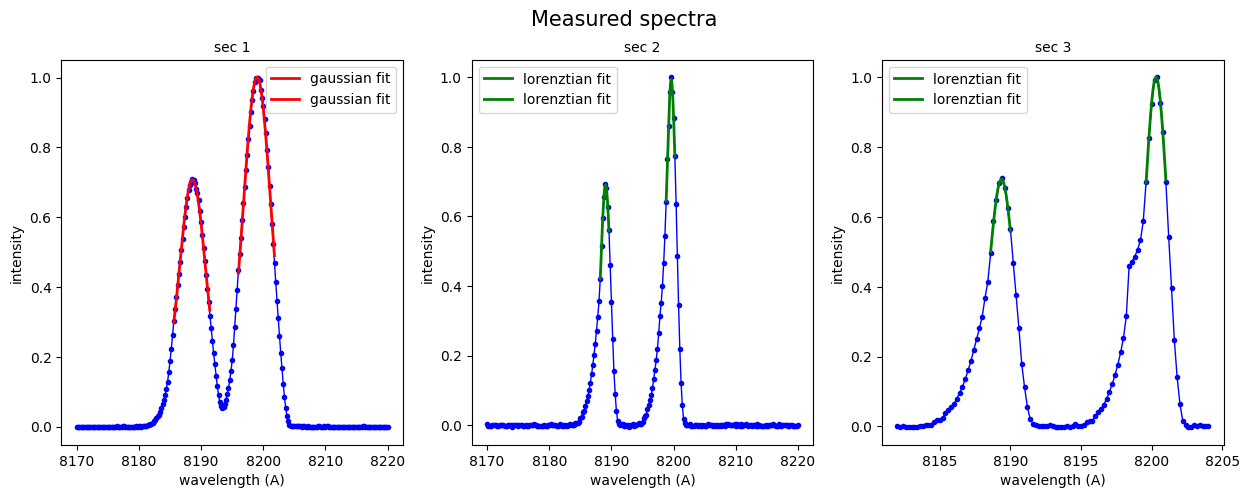

In [ ]:
# I create the figure that I am gonna populate with the fit plots
fig_sec, axs = plt.subplots(1,3, figsize = (15, 5), sharey = False, sharex = False)
axs[0].plot(sec_1[:,0], sec_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
axs[1].plot(sec_2[:,0], sec_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
axs[2].plot(sec_3[:,0], sec_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
axs[0].set_title('sec 1', fontsize = 10)
axs[1].set_title('sec 2', fontsize = 10)
axs[2].set_title('sec 3', fontsize = 10)
fig_sec.suptitle('Measured spectra', fontsize = 15)
for ax in fig_sec.axes:
    ax.set_xlabel('wavelength (A)', fontsize = 10)
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

# I execute the fits and populate the figure

for kk in range (len(sec_meas)): # loop over the measurements
    # I select a different neighborhood for sec_1 due to the higher resolution of the data
    if kk == 0:
        pk_1, pk_2 = ff.select_2peaks(sec_meas[kk], 20, 15, 0.1) # this selects a neighborhood of the two peaks
    else:
        pk_1, pk_2 = ff.select_2peaks(sec_meas[kk], 20, 4, 0.1) # this selects a neighborhood of the two peaks
    pk_ranges = (pk_1, pk_2)
    for jj in (0,1): # loop over the peak 1 and 2 of each measurement
        pk = pk_ranges[jj] # selects which peak is to be analized
        mean = np.average(pk[:,0], weights=pk[:,1])
        sigma = np.std(pk[:,0], mean=mean)
        p_guess = ([1, mean, sigma, 0]) #starting point in the fit (a, x0, gamma, y0): ESSENTIAL
        g_param, g_cov, g_infodict, ier, msg = curve_fit(ff.gaussian, pk[:,0], pk[:,1], p_guess, full_output=True)
        l_param, l_cov, l_infodict, ier, msg = curve_fit(ff.lorentzian, pk[:,0], pk[:,1], p_guess, full_output=True)
        # assuming independent variables
        g_confidence = sum(g_infodict["fvec"]**2) 
        l_confidence = sum(l_infodict["fvec"]**2)
        # sum of squared residulas, used as a measure of the goodness of the fit (the smaller the better)
        g_confidence = sum(g_infodict["fvec"]**2)
        l_confidence = sum(l_infodict["fvec"]**2)
        
        # I decide which fit (function) is to be used
        if g_confidence < l_confidence:
            
            # I populate the max vector
            max_sec[0,kk,jj] = g_param[1]
            max_sec[1,kk,jj] = g_err[1]

            # I populate the FWHM vector
            FWHM_sec[0,kk,jj] = 2.3548*g_param[2]
            FWHM_sec[1,kk,jj] = 2.3548*g_err[2]

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[kk].plot(xrange,ff.gaussian(xrange,*g_param), color = 'red', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "gaussian fit")
            axs[kk].legend(fontsize = 10)
        else: 
            # I populate the max vector
            max_sec[0,kk,jj] = l_param[1]
            max_sec[1,kk,jj] = l_err[1]

            # I populate the FWHM vector
            FWHM_sec[0,kk,jj] = 2*l_param[2]
            FWHM_sec[1,kk,jj] = 2*l_err[2]

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[kk].plot(xrange,ff.lorentzian(xrange,*l_param), color = 'green', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "lorenztian fit")
            axs[kk].legend(fontsize = 10)

## Analisi FWHM

I valori della FWHM sono già stati calcolati durante la procedura di fitting: li plotto in funzione dell'apertura della slit per osservarne l'andamento.

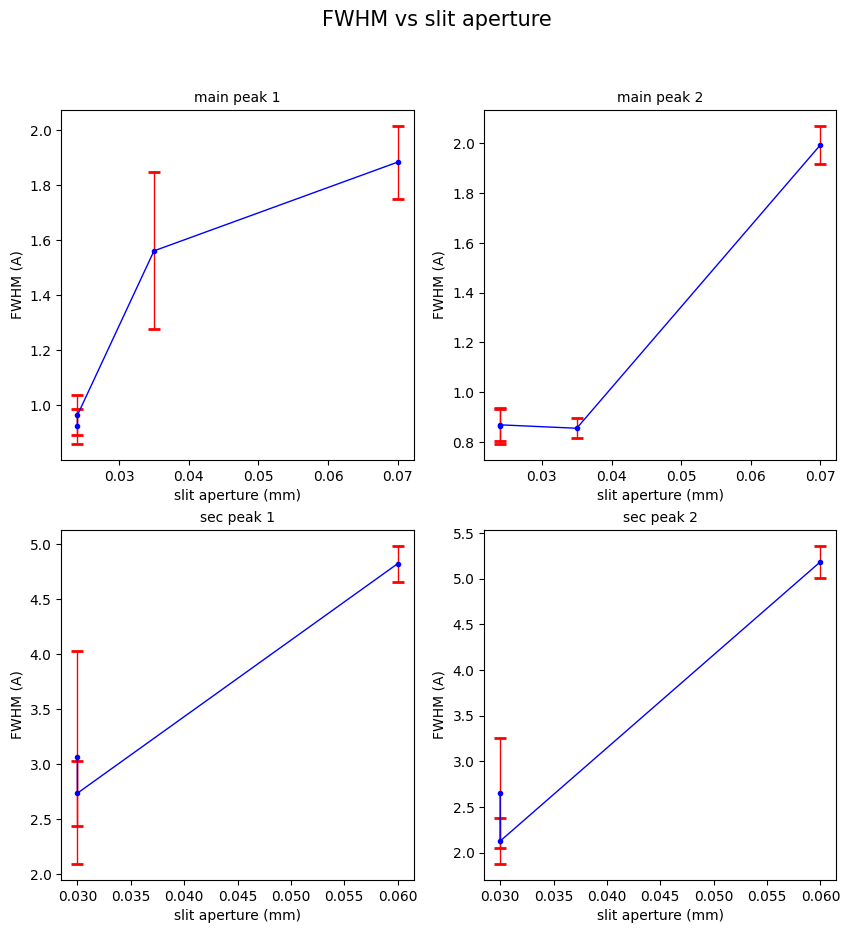

In [40]:
fig_main, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2, 2, figsize = (10, 10), sharey = False, sharex = False)
ax1.errorbar(main_slits,FWHM_main[0,:,0], yerr = FWHM_main[1,:,0], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax2.errorbar(main_slits,FWHM_main[0,:,1], yerr = FWHM_main[1,:,1], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax3.errorbar(sec_slits,FWHM_sec[0,:,0], yerr = FWHM_sec[1,:,0], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax4.errorbar(sec_slits,FWHM_sec[0,:,1], yerr = FWHM_sec[1,:,1], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax1.set_title('main peak 1', fontsize = 10)
ax2.set_title('main peak 2', fontsize = 10)
ax3.set_title('sec peak 1', fontsize = 10)
ax4.set_title('sec peak 2', fontsize = 10)
fig_main.suptitle('FWHM vs slit aperture', fontsize = 15)
for ax in fig_main.axes:
    ax.set_xlabel('slit aperture (mm)', fontsize = 10)
    ax.set_ylabel('FWHM (A)', fontsize = 10)
    ax.tick_params(labelsize = 10)

Come possiamo interpretare questi dati?
L'andamento che ci aspettiamo è una diminuzione della FWHM (all'incirca linearmente) con il ridursi dell'apertura della slit: ciò che osserviamo considerando le barre di errore ($\pm 1 \sigma$) è in linea con tale comportamento. Possiamo estrarre ulteriori informazioni dai dati relativi all'apertura inferiore delle slit, che sono doppi sia per lo spettro principale che per lo spettro secondario. Nel primo caso la misura era stata ripetuta identica senza toccare il setup in maniera da verificarne la riproducibilità: i due dati (sia relativamente al primo picco che al secondo) rientrano ampiamente nell'intervallo di confidenza l'uno dell'altro e dunque sono ampiamente compatibili. Anche nel secondo caso osserviamo che i dati sono compatibili.

## Analisi della posizione dei picchi

In [41]:
# theoretical values for the peaks
pk_main_1_th = 5889.950
pk_main_2_th = 5895.924
pk_sec_1_th = 8183.256
pk_sec_2_th = 8194.824

### Spettro principale

Per prima cosa vado a verificare se i picchi misurati (e fittati) corrispondono ai valori riportati in letteratura: se così fosse i residui dovrebbero essere non superiori all'errore sulla posizione del picco (confidence level: 1 $\sigma$).

In [42]:
# I initialize and populate the theoretical max positions
pk_th_main = np.ones((len(main_meas), 2))
pk_th_main[:,0] = pk_main_1_th*pk_th_main[:,0]
pk_th_main[:,1] = pk_main_2_th*pk_th_main[:,1]

# I calculate the residuals
res_pk_main = max_main[0,:,:] - pk_th_main

print("The residuals are [1st peak 2nd peak]:\n", res_pk_main)
print("with errors [1st peak 2nd peak]:\n", max_main[1,:,:])

The residuals are [1st peak 2nd peak]:
 [[5.04209661 4.75301578]
 [9.27155319 8.92727041]
 [6.36423022 6.06275275]
 [6.31299228 6.02888894]]
with errors [1st peak 2nd peak]:
 [[0.00727399 0.00474998]
 [0.00905504 0.0050305 ]
 [0.00640207 0.00688252]
 [0.00555604 0.00712071]]


##### Confronto intra misura

Verifico che la distanza tra il primo ed il secondo picco sia costante e compatibile con il valore teorico. Lo stepper motor che muove il monocromatore non è infallibile e nel coprire l'intero spettro accumula un certo offset tra lunghezza d'onda registrata ed effettiva. In maniera rozza abbiamo stimato un'errore di $0.2\AA$ che usiamo come errore sulla posizione dei picchi misurati (in quanto ben maggiore dell'errore sulla posizione del picco restituita dal fit).

In [43]:
gap_th_main = (pk_main_2_th-pk_main_1_th)*np.ones(len(main_meas)) # the vector contains the theoretical gap between the peaks
res_gap_main = (max_main[0,:,1]-max_main[0,:,0])-gap_th_main # residual betweem th gap value and measured one

print("The gap residuals are:\n", res_gap_main, "\u00B1", 0.4) 

The gap residuals are:
 [-0.28908082 -0.34428278 -0.30147746 -0.28410334] ± 0.4


Ciò significa che la distanza tra i picchi misurata è compatibile con il valore teorico tenendo conto della dilatazione introdotta dal motore.

#### Confronto inter misure

Ad un primo sguardo notiamo che le posizioni dei massimi teoriche e quelle misurate non sono compatibili nè con una nè con 3 $\sigma$ come confidence range. I residui variano di misura in misura: questo suggerisce che ci sia uno shift orizzontale differente ad ogni misura. Osservando che i residui delle ultime due misure sono pressochè identici e che ciò che differenzia queste due dalle altre è che non è stato alterata l'apertura delle slit (non è stato proprio toccato il setup tra una misura e la successiva) avanzo l'ipotesi che questo shift rigido orizzontale sia introdotto quando si armeggia con le slit, probabilmente a causa del meccanismo rotativo che con il passare degli anni si è "mollato".

Dalle misure fatte posso stimare la posizione del picco facendo la media e la deviazione standard delle misure 1,2 e 3 del main spectrum: sarà una stima molto più grezza (anche per le ridottissime dimensioni del campione) ma terrà conto dello shift orizzontale imputato al movimemto delle slit (ammesso e non concesso che esso segua una distribuzione gaussiana centrata in zero):

In [ ]:
mean_pk_main = np.average(max_main[0,0:-1,:], axis=0, keepdims=True, weights=1/max_main[1,0:-1,:]**2) # average over the different slit apertures
variance_pk_main = np.average((max_main[0, 0:-1, :] - mean_pk_main)**2, axis=0, keepdims=True, weights=1/max_main[1,0:-1,:]**2)
stdev_pk_main = np.sqrt(variance_pk_main)
print("mean:", mean_pk_main,"stdev:", stdev_pk_main)
# I check if the th value and the mean value are compatible:
res_mean_main = mean_pk_main - np.array([pk_main_1_th, pk_main_2_th])
print("Residuals between mean value and th [1st peak 2nd peak]:", res_mean_main)
print("With errors [1st peak 2nd peak]:", stdev_pk_main)


mean: [[5896.7986077  5902.08819549]] stdev: [[1.87880554 1.85919825]]
Residuals between mean value and th [1st peak 2nd peak]: [[6.8486077  6.16419549]]
With errors [1st peak 2nd peak]: [[1.87880554 1.85919825]]


Ancora una volta vedo che il valore calcolato con la media e la deviazione standard dei picchi fittati non è compatibile con il valore teorico (compatibile in un intervallo di 4 $\sigma$). Ciò significa che lo shift orizzontale che si origina quando vengono modificate le slit, insieme all'offset dato dall'errore sulla posizione di partenza del motore ($\sim 0.2 \AA$), non basta a spiegare il mancato accordo tra il valore teorico e il valore misurato. La spiegazione più semplice è che ci sia un'ulteriore fonte di errore, probabilmente un offset rigido (accumulato negli anni di utilizzo, che sono molti) sulla posizione del reticolo di diffrazione del monocromatore. L'entità di questo offset dipende dal confidence level che si vuole prendere sull'errore del valore di picco misurato: assumendo un confidence level di 3 $\sigma$ l'offset sul reticolo di diffrazione è $\sim 0.5 \div 1\: \AA$, non così distante dall'errore sulla posizione del reticolo che per modelli simili del monocromatore è di $0.4 \AA$.

### Spettro secondario

Seguo una procedura analoga a quella implementata per il main spectrum:

In [45]:
# I initialize and populate the theoretical max positions
pk_th_sec = np.ones((len(sec_meas), 2))
pk_th_sec[:,0] = pk_sec_1_th*pk_th_sec[:,0]
pk_th_sec[:,1] = pk_sec_2_th*pk_th_sec[:,1]

# I calculate the residuals
res_pk_sec = max_sec[0,:,:] - pk_th_sec

print("The residuals are [1st peak 2nd peak]:\n", res_pk_sec)
print("with errors [1st peak 2nd peak]:\n", max_sec[1,:,:])

The residuals are [1st peak 2nd peak]:
 [[5.35298665 4.17872452]
 [5.79735504 4.78984844]
 [6.11331841 5.48241797]]
with errors [1st peak 2nd peak]:
 [[0.00785684 0.00680842]
 [0.00543201 0.00664432]
 [0.00844891 0.00596448]]


##### Confronto intra misura

In [46]:
gap_th_sec = (pk_sec_2_th-pk_sec_1_th)*np.ones(len(sec_meas)) # the vector contains the theoretical gap between the peaks
res_gap_sec = (max_sec[0,:,1]-max_sec[0,:,0])-gap_th_sec # residual betweem th gap value and measured one

print("The gap residuals are:\n", res_gap_sec, "\u00B1", 0.4) 

The gap residuals are:
 [-1.17426212 -1.0075066  -0.63090044] ± 0.4


Ciò significa che la dilatazione introdotta dal motore non basta a spiegare la dilatazione dello spettro misurato rispetto a quello teorico. L'ulteriore dilatazione è frutto di aberrazioni introdotte dal reticolo di diffrazione per lunghezze d'onda distanti dal range ideale di utilizzo.

##### Confronto inter misure

Come prima le posizioni misurate dei picchi non sono compatibili con i valori teorici misurati. La differenza tra la risoluzione delle 3 misure acquisite, lo shift orizzontale introdotto dall'armeggiare con le slit tra la prima misura e le successive e il fatto che 1 $\AA$ misurato a queste lunghezze d'onda non corrisponda davvero ad 1 $\AA$ a causa delle aberrazioni introdotte dal monocromatore rende complicato ottenere una stima precisa delle posizioni dei picchi. Calcolo comunque la media e la deviazione standard, consapevole che lasciano il tempo che trovano: l'unica conclusione certa è che il monocromatore non è quantitativamente affidabile a queste lunghezze d'onda.

In [63]:
mean_pk_sec = np.average(max_sec[0,0:-1,:], axis=0, keepdims=True, weights=1/max_sec[1,0:-1,:]**2)
variance_pk_sec = np.average((max_sec[0, 0:-1, :] - mean_pk_sec)**2, axis=0, keepdims=True, weights=1/max_sec[1,0:-1,:]**2)
stdev_pk_sec = np.sqrt(variance_pk_sec)
print("mean:", mean_pk_sec,"stdev:", stdev_pk_sec)
# I check if the th value and the mean value are compatible:
res_mean_sec = mean_pk_sec - np.array([pk_sec_1_th, pk_sec_2_th])
print("Residuals between mean value and th [1st peak 2nd peak]:", res_mean_sec)
print("With errors [1st peak 2nd peak]:", stdev_pk_sec)

mean: [[8188.89888345 8199.34430252]] stdev: [[0.21139155 0.29970763]]
Residuals between mean value and th [1st peak 2nd peak]: [[5.64288345 4.52030252]]
With errors [1st peak 2nd peak]: [[0.21139155 0.29970763]]


## Procedura di fitting alternativa

Provo ad implementare un metodo un po' più sofisticato: $\textit{lmfit package}$. 
(questa trattazione si basa sui materiali presentati in https://lmfit.github.io/lmfit-py/index.html)

Per prima cosa importo il pacchetto lmfit e da esso il modello Gaussiano e Lorentziano

In [48]:
import lmfit as lf

In [49]:
from lmfit.models import GaussianModel
from lmfit.models import LorentzianModel

model_l = LorentzianModel()
model_g = GaussianModel()

Come prima inizializzo i vettori che conterranno la posizione dei picchi e la FWHM

In [50]:
main_meas = (main_1, main_2, main_3, main_4) # list with the main variables
# I create the vectors that I'm gonna populate when doing the fits
max_main = np.ones((2,len(main_meas),2)) # will contain the position of the max of the peaks
FWHM_main = np.ones((2,len(main_meas),2)) # will contain the FWHM of the peaks

Riutilizzo lo stesso pezzo di condice precedente, sostituendo solo le funzioni con cui viene svolto il fit:

Spettro primario:

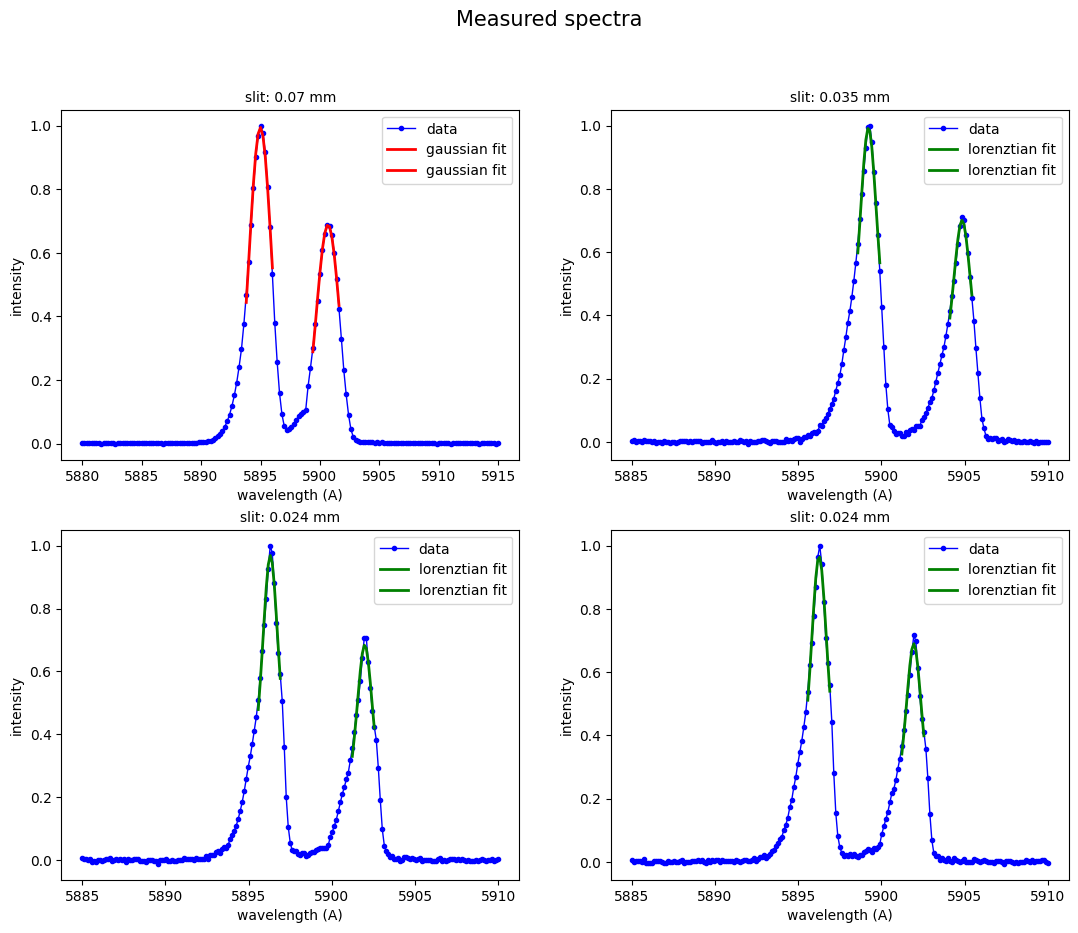

In [ ]:
# I create the figure that I am gonna populate with the fit plots
fig_main, axs = plt.subplots(2, 2, figsize = (13, 10), sharey = False, sharex = False)
axs[0][0].plot(main_1[:,0], main_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[0][1].plot(main_2[:,0], main_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[1][0].plot(main_3[:,0], main_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[1][1].plot(main_4[:,0], main_4[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[0][0].set_title('slit: 0.07 mm', fontsize = 10)
axs[0][1].set_title('slit: 0.035 mm', fontsize = 10)
axs[1][0].set_title('slit: 0.024 mm', fontsize = 10)
axs[1][1].set_title('slit: 0.024 mm', fontsize = 10)
fig_main.suptitle('Measured spectra', fontsize = 15)
for ax in fig_main.axes:
    ax.set_xlabel('wavelength (A)', fontsize = 10)
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

# The fitting procedure begins
for kk in range (len(main_meas)): # loop over the measurements
    pk_1, pk_2 = ff.select_2peaks(main_meas[kk], 20, 6, 0.1) # this selects a neighborhood of the two peaks
    pk_ranges = (pk_1, pk_2)
    for jj in (0,1): # loop over the peak 1 and 2 of each measurement
        pk = pk_ranges[jj] # selects which peak is to be analized
        g_params = model_g.guess(pk[:,1],x=pk[:,0]) # guesses the initial parameters
        g_fitted = model_g.fit(pk[:,1], g_params, x=pk[:,0]) # fits the data
        l_params = model_l.guess(pk[:,1],x=pk[:,0]) # guesses the initial parameters
        l_fitted = model_l.fit(pk[:,1], l_params, x=pk[:,0]) # fits the data
        
        # I decide which fit (function) is to be used
        if g_fitted.chisqr < l_fitted.chisqr: 
            # I populate the max vector
            max_main[0,kk,jj] = g_fitted.params['center']
            max_main[1,kk,jj] = g_fitted.uvars['center'].s
            # I populate the FWHM vector
            FWHM_main[0,kk,jj] = g_fitted.params['fwhm']
            FWHM_main[1,kk,jj] = g_fitted.uvars['fwhm'].s
            # I append the graph to the figure
            axs[int((kk+1)/3)][int((kk+2)%2)].plot(pk[:,0], g_fitted.best_fit, color = 'red', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "gaussian fit")
            axs[int((kk+1)/3)][int((kk+2)%2)].legend(fontsize = 10)
        else: 
            # I populate the max vector
            max_main[0,kk,jj] = l_fitted.params['center']
            max_main[1,kk,jj] = l_fitted.uvars['center'].s

            # I populate the FWHM vector
            FWHM_main[0,kk,jj] = l_fitted.params['fwhm']
            FWHM_main[1,kk,jj] = l_fitted.uvars['fwhm'].s

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[int((kk+1)/3)][int((kk+2)%2)].plot(pk[:,0], l_fitted.best_fit, color = 'green', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "lorenztian fit")
            axs[int((kk+1)/3)][int((kk+2)%2)].legend(fontsize = 10)



Spettro secondario:

In [52]:
sec_meas = (sec_1, sec_2, sec_3) # list with the main variables

# I create the vectors that I'm gonna populate when doing the fits
max_sec = np.ones((2,len(sec_meas),2)) # will contain the position of the max of the peaks
FWHM_sec = np.ones((2,len(sec_meas),2)) # will contain the FWHM of the peaks

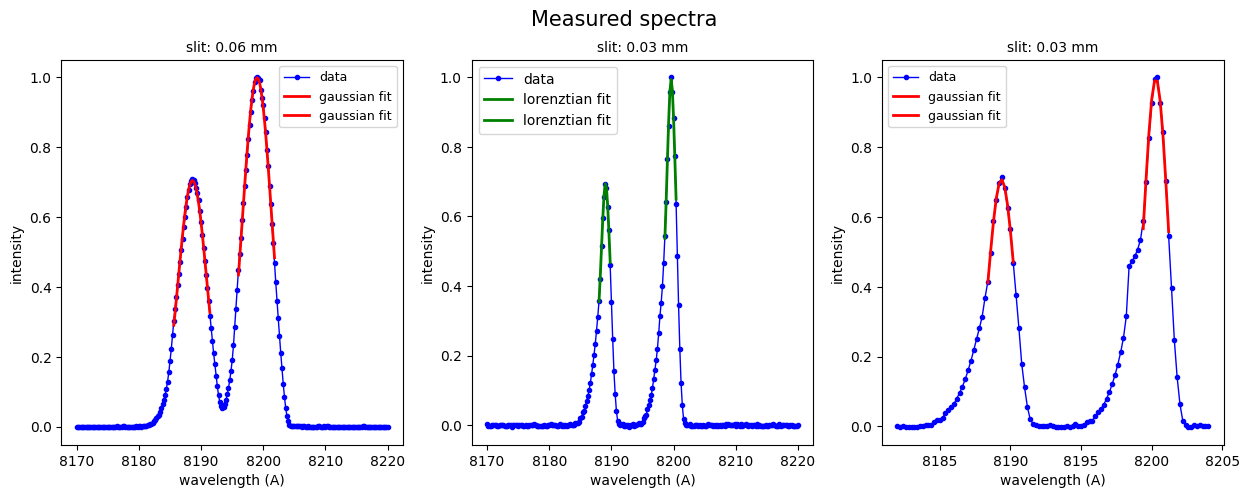

In [ ]:
# I create the figure that I am gonna populate with the fit plots
fig_sec, axs = plt.subplots(1,3, figsize = (15, 5), sharey = False, sharex = False)
axs[0].plot(sec_1[:,0], sec_1[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[1].plot(sec_2[:,0], sec_2[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[2].plot(sec_3[:,0], sec_3[:,1], color = 'blue', linewidth = 1, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3, label="data")
axs[0].set_title('slit: 0.06 mm', fontsize = 10)
axs[1].set_title('slit: 0.03 mm', fontsize = 10)
axs[2].set_title('slit: 0.03 mm', fontsize = 10)
fig_sec.suptitle('Measured spectra', fontsize = 15)
for ax in fig_sec.axes:
    ax.set_xlabel('wavelength (A)', fontsize = 10)
    ax.set_ylabel('intensity', fontsize = 10)
    ax.tick_params(labelsize = 10)

# I execute the fits and populate the figure

for kk in range (len(sec_meas)): # loop over the measurements
    # I select a different neighborhood for sec_1 due to the higher resolution of the data
    if kk == 0:
        pk_1, pk_2 = ff.select_2peaks(sec_meas[kk], 20, 15, 0.1) # this selects a neighborhood of the two peaks
    else:
        pk_1, pk_2 = ff.select_2peaks(sec_meas[kk], 20, 5, 0.1) # this selects a neighborhood of the two peaks
    pk_ranges = (pk_1, pk_2)
    for jj in (0,1): # loop over the peak 1 and 2 of each measurement
        pk = pk_ranges[jj] # selects which peak is to be analized
        g_params = model_g.guess(pk[:,1],x=pk[:,0]) # guesses the initial parameters
        g_fitted = model_g.fit(pk[:,1], g_params, x=pk[:,0]) # fits the data
        l_params = model_l.guess(pk[:,1],x=pk[:,0]) # guesses the initial parameters
        l_fitted = model_l.fit(pk[:,1], l_params, x=pk[:,0]) # fits the data

        # I decide which fit (function) is to be used
        if g_fitted.chisqr < l_fitted.chisqr:
            # I populate the max vector
            max_sec[0,kk,jj] = g_fitted.params['center']
            max_sec[1,kk,jj] = g_fitted.uvars['center'].s
            # I populate the FWHM vector
            FWHM_sec[0,kk,jj] = g_fitted.params['fwhm']
            FWHM_sec[1,kk,jj] = g_fitted.uvars['fwhm'].s
            # I append the graph to the figure
            axs[kk].plot(pk[:,0], g_fitted.best_fit, color = 'red', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "gaussian fit")
            axs[kk].legend(fontsize = 9)
        else: 
            # I populate the max vector
            max_sec[0,kk,jj] = l_fitted.params['center']
            max_sec[1,kk,jj] = l_fitted.uvars['center'].s

            # I populate the FWHM vector
            FWHM_sec[0,kk,jj] = l_fitted.params['fwhm']
            FWHM_sec[1,kk,jj] = l_fitted.uvars['fwhm'].s

            # I append the graph to the figure
            xrange = np.arange(pk[0,0],pk[-1,0],0.01)
            axs[kk].plot(pk[:,0], l_fitted.best_fit, color = 'green', linewidth = 2, marker='', markerfacecolor='green', markeredgecolor='green', markersize=3, label= "lorenztian fit")
            axs[kk].legend(fontsize = 10)

FWHM:

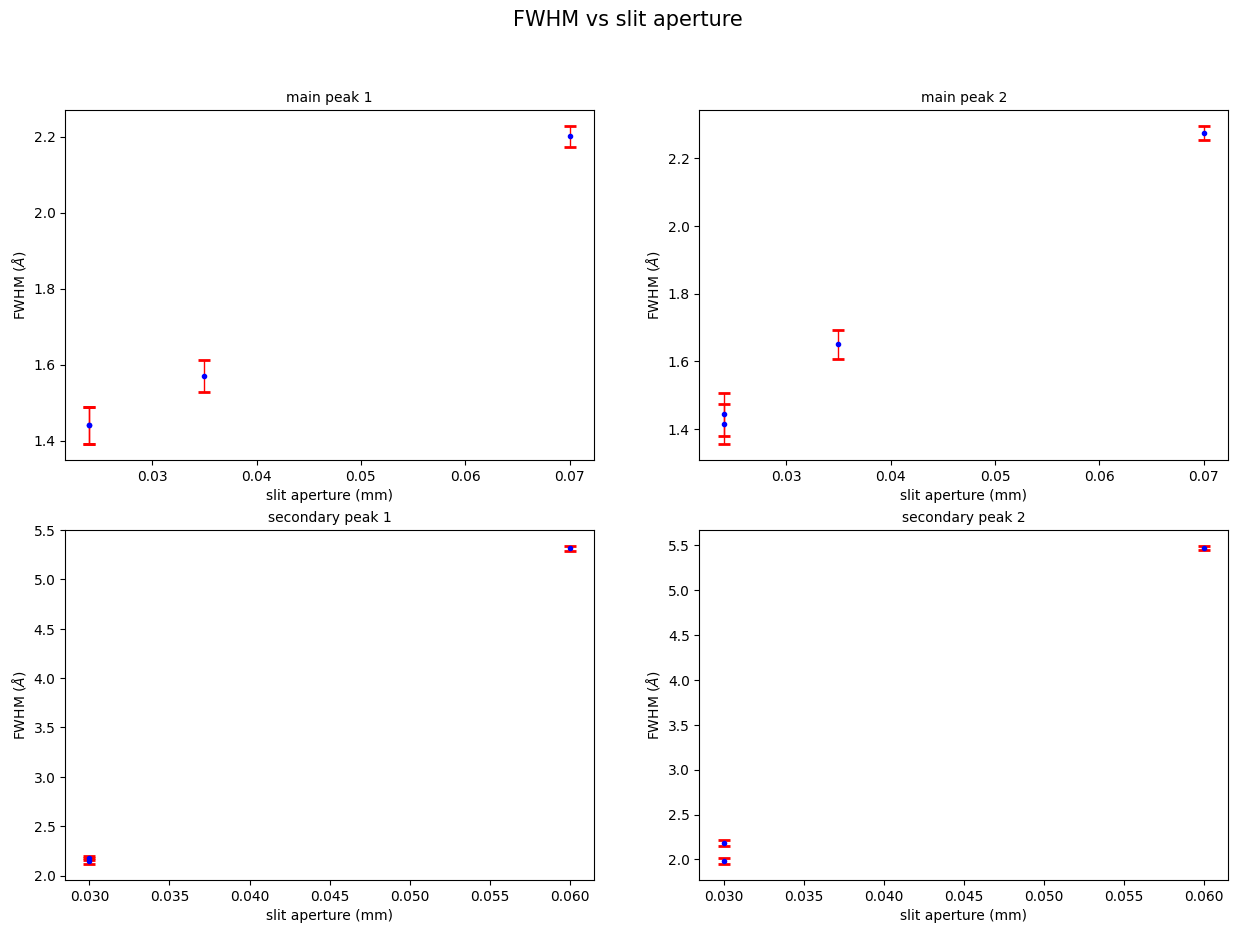

In [ ]:
fig_main, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2, 2, figsize = (15, 10), sharey = False, sharex = False)
ax1.errorbar(main_slits,FWHM_main[0,:,0], yerr = FWHM_main[1,:,0], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 0, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax2.errorbar(main_slits,FWHM_main[0,:,1], yerr = FWHM_main[1,:,1], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 0, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax3.errorbar(sec_slits,FWHM_sec[0,:,0], yerr = FWHM_sec[1,:,0], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 0, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax4.errorbar(sec_slits,FWHM_sec[0,:,1], yerr = FWHM_sec[1,:,1], xerr=None, ecolor = 'red', elinewidth = 1, capsize = 4, capthick = 2, color = 'blue', linewidth = 0, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3)
ax1.set_title('main peak 1', fontsize = 10)
ax2.set_title('main peak 2', fontsize = 10)
ax3.set_title('secondary peak 1', fontsize = 10)
ax4.set_title('secondary peak 2', fontsize = 10)
fig_main.suptitle('FWHM vs slit aperture', fontsize = 15)
for ax in fig_main.axes:
    ax.set_xlabel('slit aperture (mm)', fontsize = 10)
    ax.set_ylabel('FWHM ($\AA$)', fontsize = 10)
    ax.tick_params(labelsize = 10)

Implementare questa procedura di fitting all'interno dello stesso codice mostra solo parzialmente la potenza di questo secondo approccio: per avere un'idea del vantaggio posso stampare il "fit_report" dell'ultimo fit effettuato:

In [ ]:
print(l_fitted.fit_report())

[[Model]]
    Model(lorentzian)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 10
    # variables        = 3
    chi-square         = 0.00198591
    reduced chi-square = 2.8370e-04
    Akaike info crit   = -79.2426084
    Bayesian info crit = -78.3348531
    R-squared          = 0.99178922
[[Variables]]
    amplitude:  3.30457845 +/- 0.05909872 (1.79%) (init = 0.8549852)
    center:     8200.29585 +/- 0.01041853 (0.00%) (init = 8200.3)
    sigma:      1.04207367 +/- 0.02463790 (2.36%) (init = 0.5001931)
    fwhm:       2.08414734 +/- 0.04927579 (2.36%) == '2.0000000*sigma'
    height:     1.00941044 +/- 0.00963401 (0.95%) == '0.3183099*amplitude/max(1e-15, sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma) = +0.9315


Oppure il fatto che con una riga di codice posso ottenere il plot del mio fit:

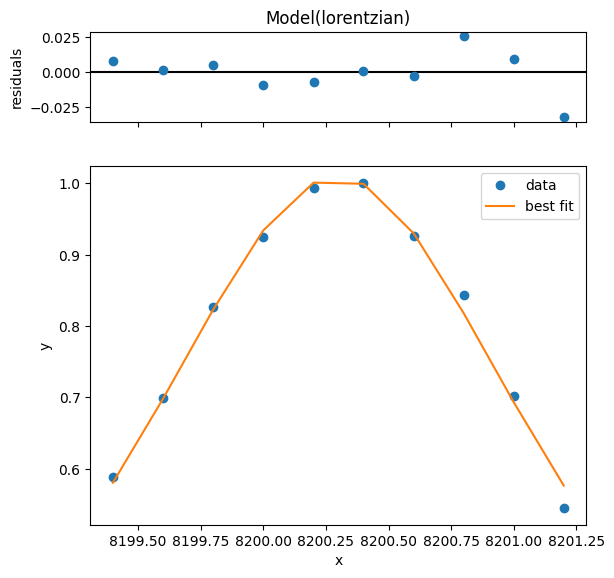

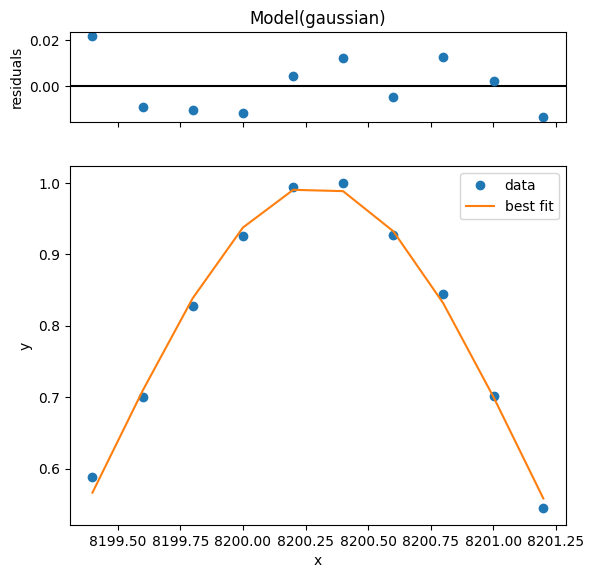

In [56]:
figure = l_fitted.plot()
figure = g_fitted.plot()

O ancora che $\textit{lmfit}$ permette di fittare un dataset attraverso una convoluzione di funzioni semplicemente "sommando" i modelli delle funzioni base.

## Further development:

Il passo successivo nella procedura di analisi dati portata avanti in questo notebook sarebbe quello di implementare (attraverso cicli for o funzioni definite su moduli esterni) una maggiore automazione del processo in modo che non vi siano snippet di codice copiati e incollati ove cambia solamente il nome di una variabile. In particolare sarebbe importante: 
- automatizzare l'import dei file tramite OS
- ciclare sui diversi dataset, possibilmente in maniera unica all'inizio dell'analisi
- automatizzare la creazione delle stringhe di testo in modo da evitare di definirle "a mano" per ogni grafico
